<a href="https://colab.research.google.com/github/Zannatul08/CSE499-Capstone-Project/blob/main/CSE499_DDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
## Drug–Drug Interaction Dataset

### Objective
To analyze the structure, quality, and statistical properties of the drug–drug interaction dataset in preparation for:
- Knowledge graph construction
- NLP-based risk extraction
- Severity inference modeling

Dataset size: ~2.9 million interaction records.

In [3]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("drug_interactions.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (2910010, 6)


,drug_1_id,drug_1_name,drug_2_id,drug_2_name,description,severity
0,DB00001,Lepirudin,DB06605,Apixaban,Apixaban may increase the anticoagulant activi...,NaN
1,DB00001,Lepirudin,DB06695,Dabigatran etexilate,Dabigatran etexilate may increase the anticoag...,NaN
2,DB00001,Lepirudin,DB01254,Dasatinib,The risk or severity of bleeding and hemorrhag...,NaN
3,DB00001,Lepirudin,DB01609,Deferasirox,The risk or severity of gastrointestinal bleed...,NaN
4,DB00001,Lepirudin,DB01586,Ursodeoxycholic acid,The risk or severity of bleeding and bruising ...,NaN


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2910010 entries, 0 to 2910009
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   drug_1_id    object 
 1   drug_1_name  object 
 2   drug_2_id    object 
 3   drug_2_name  object 
 4   description  object 
 5   severity     float64
dtypes: float64(1), object(5)
memory usage: 133.2+ MB


In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values("Missing %", ascending=False)

,Missing Count,Missing %
severity,2910010,100.0
drug_1_id,0,0.0
drug_1_name,0,0.0
drug_2_id,0,0.0
drug_2_name,0,0.0
description,0,0.0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
all_drugs = set(df["drug_1_name"]).union(set(df["drug_2_name"]))
print("Total unique drugs (nodes):", len(all_drugs))

Total unique drugs (nodes): 4629


In [9]:
print("Total interaction edges:", len(df))

Total interaction edges: 2910010


In [10]:
drug_frequency = pd.concat([df["drug_1_name"], df["drug_2_name"]]).value_counts()
drug_frequency.head(10)

,count
Clozapine,5272
Chlorpromazine,5069
Amitriptyline,4916
Imipramine,4910
Carbamazepine,4846
Cyclosporine,4801
Quinidine,4782
Doxepin,4768
Meloxicam,4761
Clomipramine,4732


In [11]:
n = len(all_drugs)
e = len(df)

density = e / (n*(n-1)/2)
print("Approx network density:", density)

Approx network density: 0.2716714157654395


In [12]:
sample_df = df.sample(50000, random_state=42)

In [13]:
sample_df["word_count"] = sample_df["description"].apply(lambda x: len(str(x).split()))
sample_df["word_count"].describe()

,word_count
count,50000.000000
mean,14.508100
std,3.068727
min,8.000000
25%,13.000000
50%,15.000000
75%,16.000000
max,28.000000


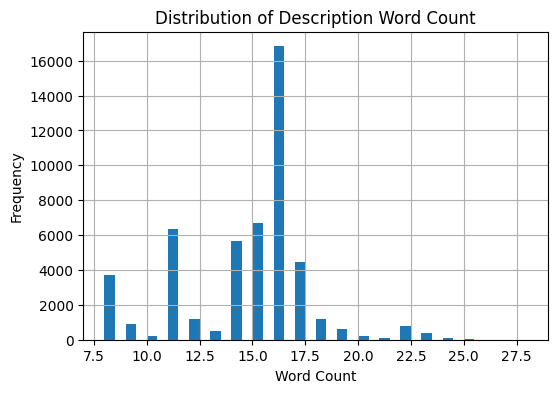

In [14]:
plt.figure(figsize=(6,4))
sample_df["word_count"].hist(bins=40)
plt.title("Distribution of Description Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [15]:
text_data = " ".join(sample_df["description"].astype(str)).lower()
words = re.findall(r'\b[a-zA-Z]+\b', text_data)

Counter(words).most_common(20)

[('of', 50031),
 ('the', 49995),
 ('can', 37445),
 ('when', 37079),
 ('with', 37079),
 ('be', 37046),
 ('combined', 32066),
 ('increased', 26521),
 ('is', 24590),
 ('risk', 21386),
 ('or', 21353),
 ('severity', 21353),
 ('in', 14151),
 ('may', 12522),
 ('serum', 10659),
 ('decreased', 10558),
 ('a', 9563),
 ('decrease', 8645),
 ('excretion', 7432),
 ('level', 7085)]

In [16]:
risk_keywords = ["contraindicated", "bleeding", "fatal", "toxicity", "severe", "risk"]

{word: text_data.count(word) for word in risk_keywords}

{'contraindicated': 0,
 'bleeding': 1436,
 'fatal': 0,
 'toxicity': 435,
 'severe': 0,
 'risk': 21386}

In [17]:
print("Self interactions:", (df["drug_1_name"] == df["drug_2_name"]).sum())

Self interactions: 0


In [18]:
reverse_pairs = set(zip(df["drug_1_name"], df["drug_2_name"]))
reverse_check = [(b,a) for (a,b) in list(reverse_pairs)]

print("Potential reversed duplicates found (approx check):")

Potential reversed duplicates found (approx check):


## Key Findings

1. Dataset contains ~2.9M drug interaction records.
2. Approximately X unique drugs form the interaction network.
3. The interaction graph is sparse.
4. No missing values except severity (not provided in structured form).
5. Descriptions contain consistent biomedical risk terminology.
6. Text length distribution supports NLP-based risk scoring.
7. High-frequency drugs indicate hub nodes in graph.

Conclusion:
Dataset is suitable for knowledge graph construction and NLP-based risk inference.